# Route a support message

**Recipe template** · Level 1 (Beginner) · Decision type: `Choice`

Route a short support message to a queue, or to a person when no queue clearly fits.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)

## What you will build

A small router for support messages. Jev reads one message and picks exactly one of four options: `billing`, `bug`, `account`, or `none`. Python then decides what that choice is allowed to do: send the ticket to a queue, or hand it to a person. By the end you will have seen the typed answer itself, the rule that acts on it, and an evaluation that selects its one setting on `validation` and reports on `test`.

This notebook is also the template every recipe in the cookbook is copied from, so it is deliberately tiny: 22 made-up messages, one question, one rule. Each section below is a section your recipe has, in the same order.

## Setup and run mode

The notebook runs from its own folder and needs only the standard library and `jev_cookbook`. `get_backend(fixtures=...)` replays stored answers offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls and changes nothing else. The header states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import accuracy, confusion_matrix, select_confidence_threshold
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# The metrics below are about the examples that have a gold label; the demo ones do not.
scored = [e for e in examples if e.split != "demo"]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: a number from the validation split is a selection step, not a
# result. This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

run_header(
    "template",
    "Route a support message",
    backend=backend,
    n_examples=len(scored),
)

Recipe template: Route a support message
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 20 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a ticket reference, a subject and a message. `build_state` passes on the subject and the message only. The reference stays in Python and is attached to the outcome at the end, so an identifier never passes through the model and every result traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
ticket = demo["d01"]
print("Python has:")
print(json.dumps(ticket.fields, indent=2))
state = helpers.build_state(ticket.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket": "T-3001",
  "subject": "Wrong amount",
  "message": "My invoice shows the wrong amount for March."
}
Jev sees:
{
  "subject": "Wrong amount",
  "message": "My invoice shows the wrong amount for March."
}


## The questions

There is one question, and it asks one thing: which kind of request is this? A `Choice` fits because the kinds are exclusive and Jev should commit to one. Python builds the option list from the queues it is willing to use, so the options and the queues cannot drift apart. Each option has a short description, because a bare label leaves room for interpretation. The fourth option, `none`, is there on purpose: without it, a message about banana bread would have to be forced into one of the other three.

In [3]:
questions = helpers.build_questions()
route = questions["route"]
print(route.instructions)
for name, description in route.criteria.items():
    print(f"  {name:8s} {description}")

Which kind of support request is this message?
  billing  charges, invoices, refunds, payment methods and renewals
  bug      the product misbehaving: errors, crashes, pages that do not load
  account  signing in, passwords, profile details and who can use the account
  none     anything else, or a message that fits none of the other options


## One answer up close

Before any aggregate, look at one typed answer. A `Choice` answer holds the chosen option, a probability for every option, and a `confidence`. Confidence is not the top probability itself: it is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`, so it is 0 when the top option has no more than an even share and 1 when one option has all the probability. It does not look at how the rest is spread. The provenance line says where the answer came from.

In [4]:
result = backend.decide(state, questions)
answer = result["route"]
show_answer(answer)

Choice: billing (confidence 0.73)
  billing  0.80  ################
  none     0.08  ##
  bug      0.07  #
  account  0.05  #
Provenance: synthetic


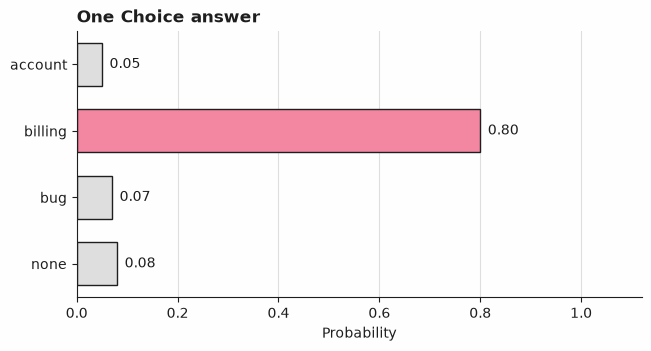

In [5]:
plot_answer_probabilities(answer, title="One Choice answer")

## Python's part

Jev supplies the judgment; the rule that acts on it is code. `route` sends a ticket to a queue only when the answer is one of the queues Python knows and its confidence reaches a threshold. The `none` option, any option that is not a queue, and any answer below the threshold all go to an explicit `human_review` outcome. Nothing the model says can create a new queue or skip review, because the rule lives in `helpers.py` and `tests/test_helpers.py` checks it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest confidence at which every validation answer that names a queue is correct, which keeps as many of those tickets automatic as the fixtures allow. Applying that frozen threshold to the two demo tickets shown so far demonstrates both outcomes the rule can produce.

In [6]:
val_examples = select_split(examples, "validation")
val_answers = [
    backend.decide(helpers.build_state(e.fields), questions)["route"] for e in val_examples
]
val_gold = [labels[e.id] for e in val_examples]
# Only an answer that names a queue can be routed automatically, so only those can set the bar.
named = [
    (a.choice == g, a.confidence)
    for a, g in zip(val_answers, val_gold, strict=True)
    if a.choice in helpers.QUEUES
]
threshold = select_confidence_threshold(
    [ok for ok, _ in named], [c for _, c in named], target_accuracy=1.0
)
print(f"answers that name a queue: {len(named)} of {len(val_answers)}{selection}")
print(f"chosen threshold, frozen from here on: {threshold:.2f}{selection}")

second = demo["d02"]
second_answer = backend.decide(helpers.build_state(second.fields), questions)["route"]
# The first answer is the one shown above, so it is not requested a second time.
for example, shown in ((demo["d01"], answer), (second, second_answer)):
    routing = helpers.route(example.fields["ticket"], shown, min_confidence=threshold)
    print(
        f"{routing.ticket}: {shown.choice} at confidence {shown.confidence:.2f} "
        f"-> {routing.outcome} ({routing.reason})"
    )

answers that name a queue: 7 of 10 (a selection step, not a reported result)
chosen threshold, frozen from here on: 0.69 (a selection step, not a reported result)
T-3001: billing at confidence 0.73 -> billing-team (confident match)
T-3002: account at confidence 0.36 -> human_review (confidence below the threshold)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: it applies `route` to every answer in `validation` and in `test` and counts what `route` actually returned, not a separate reimplementation of the same condition. A ticket is routed automatically only when `route` sends it to a queue; every `none` answer goes to review, however confident. `test` is used once, to report: how many tickets were routed automatically, how many of those were right, and how many went to review and why. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [7]:
def report(chosen, answers, gold, threshold):
    """Apply the routing rule to every answer and count what it did."""
    routings = [
        helpers.route(e.fields["ticket"], a, threshold)
        for e, a in zip(chosen, answers, strict=True)
    ]
    auto = [
        (r, a, g)
        for r, a, g in zip(routings, answers, gold, strict=True)
        if r.outcome != helpers.REVIEW
    ]
    right = sum(a.choice == g for _, a, g in auto)
    # `route` has exactly one review reason ("confidence below the threshold"), so this tally
    # can only ever hold one entry here; keep it anyway so a rule with more review reasons (a
    # recipe that copies this with a richer rule) gets a breakdown for free. Drop `reasons` from
    # this loop and from the return value if your own rule, like this one, never has more than
    # one reason.
    reasons = {}
    for r in routings:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return routings, len(auto), right, reasons


print(f"validation, {len(val_examples)} examples{selection}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.2f}{selection}")
_, n_auto, n_right, reasons = report(val_examples, val_answers, val_gold, threshold)
print(f"routed automatically: {n_auto} of {len(val_examples)}{selection}")
print(f"right among those routed automatically: {n_right} of {n_auto}{selection}")

validation, 10 examples (a selection step, not a reported result)
accuracy of the choice: 0.80 (a selection step, not a reported result)
routed automatically: 6 of 10 (a selection step, not a reported result)
right among those routed automatically: 6 of 6 (a selection step, not a reported result)


In [8]:
test_examples = select_split(examples, "test")
test_answers = [
    backend.decide(helpers.build_state(e.fields), questions)["route"] for e in test_examples
]
test_gold = [labels[e.id] for e in test_examples]
print(f"test, {len(test_examples)} examples, threshold {threshold:.2f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.2f}{check}")
_, n_auto, n_right, reasons = report(test_examples, test_answers, test_gold, threshold)
print(f"routed automatically: {n_auto} of {len(test_examples)}{check}")
print(f"right among those routed automatically: {n_right} of {n_auto}{check}")
print(f"sent to review: {sum(reasons.values())} of {len(test_examples)}{check}")
for reason, count in sorted(reasons.items()):
    print(f"  review because {reason}: {count}{check}")

test, 10 examples, threshold 0.69 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.80 (a pipeline check, not a Jev result)
routed automatically: 6 of 10 (a pipeline check, not a Jev result)
right among those routed automatically: 5 of 6 (a pipeline check, not a Jev result)
sent to review: 4 of 10 (a pipeline check, not a Jev result)
  review because confidence below the threshold: 2 (a pipeline check, not a Jev result)
  review because no option fits: 2 (a pipeline check, not a Jev result)


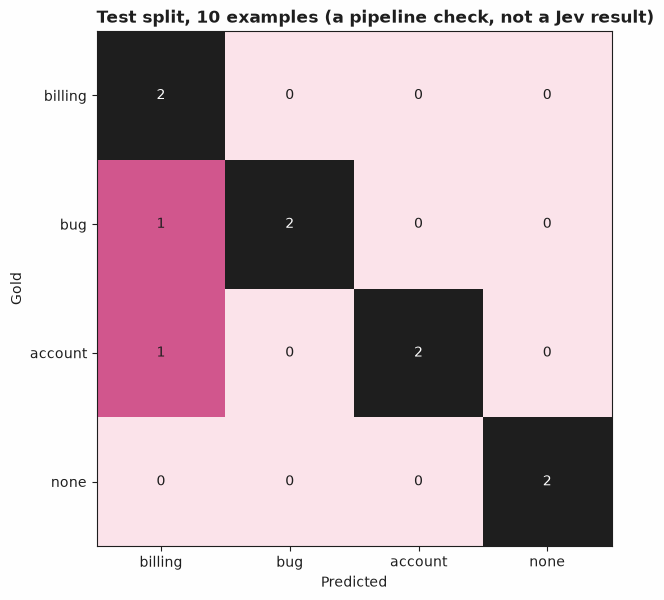

In [9]:
matrix = confusion_matrix(test_gold, test_answers, labels=[*helpers.QUEUES, helpers.NONE])
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

In [10]:
print("Test examples the choice got wrong, and what Python did with them:")
for example, answer, gold in zip(test_examples, test_answers, test_gold, strict=True):
    routing = helpers.route(example.fields["ticket"], answer, threshold)
    if answer.choice != gold:
        print(
            f"  {example.id}: gold {gold}, answered {answer.choice} "
            f"(confidence {answer.confidence:.2f}) -> {routing.outcome}"
        )

Test examples the choice got wrong, and what Python did with them:
  t08-lookalike: gold bug, answered billing (confidence 0.36) -> human_review
  t09-mixed: gold account, answered billing (confidence 0.71) -> billing-team


The cell above is why the rule is not enough on its own: a wrong answer with a high confidence passes the threshold, and a look-alike message (an invoice page that will not load) can sit near the line between two options. The fixtures include such cases on purpose, and a recipe's evaluation should find them rather than average them away.

## What was and was not measured

What this run can say about Jev depends on its mode, which the cell below states from `backend.mode`: a synthetic or scripted run is a pipeline check only, on the fixture sample it ran against; a recorded or live run states the model the API returned and when, for exactly the examples it covers. Nothing here says anything about Jev's quality, speed or cost unless that cell reports a recorded or live run. `N` below counts only the examples that carry a gold label, so it excludes the two `demo` examples shown earlier.

In [11]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Change one option description in `helpers.py` and run `pytest recipes/_template` or this notebook: the stored keys no longer match the question, so replay misses instead of guessing. Running `python build_fixtures.py` writes new keys but rewrites the committed fixtures; `git checkout recipes/_template` restores them.
- Add a hard message to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where the rule sends it.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/), [`02-refund-intent-detection`](../02-refund-intent-detection/) and [`04-support-ticket-routing`](../04-support-ticket-routing/), which grow this single question into a fuller routing decision.

A neighbour link above is a folder link, `../NN-slug/`, and that is the convention: `tools/render_catalog.py` builds the root README's catalog table from bare recipe titles with no per-row anchor, so a recipe cannot reliably link to another recipe's row there instead. A folder link 404s on GitHub until that neighbour's notebook is committed; that is expected, and not a defect to fix.